In [ ]:
pip install opencv-python mediapipe numpy pandas

INFO: pip is looking at multiple versions of mediapipe to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 24.0 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.5
    Uninstalling protobuf-5.29.5:
      Successfully uninstalled protobuf-5.29.5
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.8 which is incompatible.
ydf 0.13.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.8 which is incompatible.
opentelemetry-proto 1.37.0 requires protobuf<7.0,>=5.0, but you have protobuf 4.25.8 which is incompatible.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import cv2
import json
import glob
import numpy as np
import pandas as pd
import mediapipe as mp
import gc  # Garbage Collector interface
from datetime import datetime
from google.colab import drive

# ================= CONFIGURATION =================
# Mount Drive (Run this only once in a separate cell usually)
# drive.mount('/content/drive')

# Base Directory containing all subject folders (unzipped)
# Structure: /content/drive/MyDrive/Dataset/subject_01/, /subject_02/...
DATASET_ROOT = "/content/drive/MyDrive/Behaviour Dataset"
OUTPUT_DIR = "/content/drive/MyDrive/Processed_Clips_v1"

IMG_SIZE = 224
CLIP_LENGTH = 16
STRIDE = 8
MAX_MISSING_FACES = 8  # 50% allowed missing

# ================= HELPER FUNCTIONS =================

def map_attention(score):
    """Maps 1-5 scale to 3 classes."""
    if score <= 2.4: return 0      # Low
    elif score <= 3.6: return 1    # Mid
    else: return 2                 # High

def parse_timestamp(ts_str, is_filename=False):
    """Parses timestamp strings into datetime objects."""
    try:
        if is_filename:
            # Filename: 12_41_05_323716.jpg
            base = os.path.splitext(ts_str)[0]
            parts = base.split('_')
            clean = f"{parts[0]}:{parts[1]}:{parts[2]}.{parts[3]}"
        else:
            # JSON: 12:41:05:323716
            parts = ts_str.split(':')
            clean = f"{parts[0]}:{parts[1]}:{parts[2]}.{parts[3]}"
        return datetime.strptime(clean, "%H:%M:%S.%f")
    except Exception:
        return None

def get_aggregated_labels(label_dir, image_files):
    """
    Combines 4 labeler JSONs and maps them to images.
    Returns: dict { 'filename.jpg': class_int }
    """
    json_files = glob.glob(os.path.join(label_dir, "*.json"))
    all_records = []

    # 1. Load all JSON entries
    for jf in json_files:
        with open(jf, 'r') as f:
            data = json.load(f)
            for entry in data:
                ts = parse_timestamp(entry['datetime'])
                if ts:
                    # Default to Mid(3) if missing
                    val = float(entry.get('attention', 3))
                    all_records.append({'time': ts, 'val': val})

    if not all_records: return {}

    # 2. Sort by time for faster matching
    df = pd.DataFrame(all_records).sort_values('time').reset_index(drop=True)

    # 3. Match images to average label
    img_labels = {}

    # Optimization: Convert times to numeric arrays for fast searching
    # (Using arbitrary reference time to convert to float seconds)
    ref_time = df['time'].iloc[0]

    def to_seconds(t):
        return (t - ref_time).total_seconds()

    label_times = df['time'].apply(to_seconds).values
    label_vals = df['val'].values

    for img_path in image_files:
        img_name = os.path.basename(img_path)
        img_ts = parse_timestamp(img_name, is_filename=True)
        if not img_ts: continue

        t_sec = to_seconds(img_ts)

        # Find closest timestamp index
        idx = (np.abs(label_times - t_sec)).argmin()

        # Check if the closest label is within reasonable range (e.g. 1 sec)
        if abs(label_times[idx] - t_sec) < 1.0:
            # In a real scenario, you might average multiple labels around this time
            # For speed, we take the nearest single entry or average if duplicates exist at that exact index
            final_class = map_attention(label_vals[idx])
            img_labels[img_name] = final_class

    return img_labels

def process_single_subject(subject_path, output_dir):
    subject_id = os.path.basename(subject_path)

    # Paths
    img_dir = os.path.join(subject_path, "images")
    lbl_dir = os.path.join(subject_path, "labels")

    if not os.path.exists(img_dir): return

    print(f"\n[{subject_id}] Reading images...")
    img_files = sorted(glob.glob(os.path.join(img_dir, "*.png")))

    if len(img_files) < CLIP_LENGTH:
        print(f"[{subject_id}] Not enough images. Skipping.")
        return

    # 1. Get Labels
    labels_map = get_aggregated_labels(lbl_dir, img_files)
    print(f"[{subject_id}] Matched {len(labels_map)} labeled frames.")

    # 2. Initialize MediaPipe (Short Range = Faster on CPU)
    mp_face = mp.solutions.face_detection
    detector = mp_face.FaceDetection(model_selection=0, min_detection_confidence=0.5)

    # Buffers
    X_clips = []
    y_clips = []

    buffer_imgs = []
    buffer_lbls = []
    buffer_imputed = [] # 0=Real, 1=Imputed

    last_box = None # (x, y, w, h)

    print(f"[{subject_id}] Processing video stream...")

    # Process frames
    for img_path in img_files:
        fname = os.path.basename(img_path)
        if fname not in labels_map: continue

        # Read
        frame = cv2.imread(img_path)
        if frame is None: continue

        h_img, w_img, _ = frame.shape
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        # Detect
        results = detector.process(rgb)

        # Crop Logic
        crop = None
        is_imputed = 0

        if results.detections:
            # Face Found
            det = results.detections[0].location_data.relative_bounding_box
            x = int(det.xmin * w_img)
            y = int(det.ymin * h_img)
            w = int(det.width * w_img)
            h = int(det.height * h_img)

            # Padding
            pad = 15
            x, y = max(0, x-pad), max(0, y-pad)
            w, h = min(w_img-x, w+2*pad), min(h_img-y, h+2*pad)

            last_box = (x, y, w, h)
            crop = frame[y:y+h, x:x+w]

        elif last_box is not None:
            # Face Lost -> Use Memory
            x, y, w, h = last_box
            crop = frame[y:y+h, x:x+w]
            is_imputed = 1

        # If no face found yet, skip
        if crop is None: continue

        # Resize & Normalize
        try:
            crop = cv2.resize(crop, (IMG_SIZE, IMG_SIZE))
            # Keep uint8 (0-255) to save RAM! Normalize during training.
            # Using float32 here increases RAM usage by 4x.
        except:
            continue

        # Add to buffer
        buffer_imgs.append(crop)
        buffer_lbls.append(labels_map[fname])
        buffer_imputed.append(is_imputed)

        # Create Clip
        if len(buffer_imgs) == CLIP_LENGTH:
            # Quality Check
            if sum(buffer_imputed) <= MAX_MISSING_FACES:
                # Majority Vote for Label
                cls = max(set(buffer_lbls), key=buffer_lbls.count)

                X_clips.append(np.array(buffer_imgs))
                y_clips.append(cls)

            # Stride: Remove first N elements
            buffer_imgs = buffer_imgs[STRIDE:]
            buffer_lbls = buffer_lbls[STRIDE:]
            buffer_imputed = buffer_imputed[STRIDE:]

    # Save to Disk immediately
    if len(X_clips) > 0:
        X_arr = np.array(X_clips, dtype=np.uint8) # Save as int to save space
        y_arr = np.array(y_clips, dtype=np.int64)

        out_x = os.path.join(output_dir, f"{subject_id}_X.npy")
        out_y = os.path.join(output_dir, f"{subject_id}_y.npy")

        np.save(out_x, X_arr)
        np.save(out_y, y_arr)

        print(f"[{subject_id}] SAVED: {X_arr.shape} clips to Drive.")

    # Cleanup Memory
    detector.close()
    del X_clips, y_clips, buffer_imgs, results, frame, rgb
    gc.collect() # Force RAM cleanup

# ================= RUNNER =================
if __name__ == "__main__":
    if not os.path.exists(OUTPUT_DIR):
        os.makedirs(OUTPUT_DIR)

    # Get all subject folders
    # Assuming folders are named "subject_xx"
    all_subjects = sorted(glob.glob(os.path.join(DATASET_ROOT, "subject_*")))

    print(f"Found {len(all_subjects)} subjects.")

    # Limit for testing?
    #all_subjects = all_subjects[:1]

    for subj_path in all_subjects:
        process_single_subject(subj_path, OUTPUT_DIR)

    print("\nAll processing complete.")

Found 20 subjects.

[subject_01] Reading images...
[subject_01] Matched 741 labeled frames.
[subject_01] Processing video stream...


/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


[subject_01] SAVED: (91, 16, 224, 224, 3) clips to Drive.

[subject_02] Reading images...
[subject_02] Matched 1146 labeled frames.
[subject_02] Processing video stream...


/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


[subject_02] SAVED: (142, 16, 224, 224, 3) clips to Drive.

[subject_03] Reading images...
[subject_03] Matched 741 labeled frames.
[subject_03] Processing video stream...


...

[subject_18] SAVED: (144, 16, 224, 224, 3) clips to Drive.

[subject_19] Reading images...
[subject_19] Matched 1743 labeled frames.
[subject_19] Processing video stream...


/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


[subject_19] SAVED: (216, 16, 224, 224, 3) clips to Drive.

[subject_20] Reading images...
[subject_20] Matched 695 labeled frames.
[subject_20] Processing video stream...


/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


[subject_20] SAVED: (85, 16, 224, 224, 3) clips to Drive.

All processing complete.


Scanning /content/drive/MyDrive/Processed_Clips_v1 for label files...
Found 20 subject files.

      GLOBAL DATASET STATISTICS      
Total Video Clips: 2347
Class 0 (Low Attention): 687 clips (29.27%)
Class 1 (Mid Attention): 1357 clips (57.82%)
Class 2 (High Attention): 303 clips (12.91%)


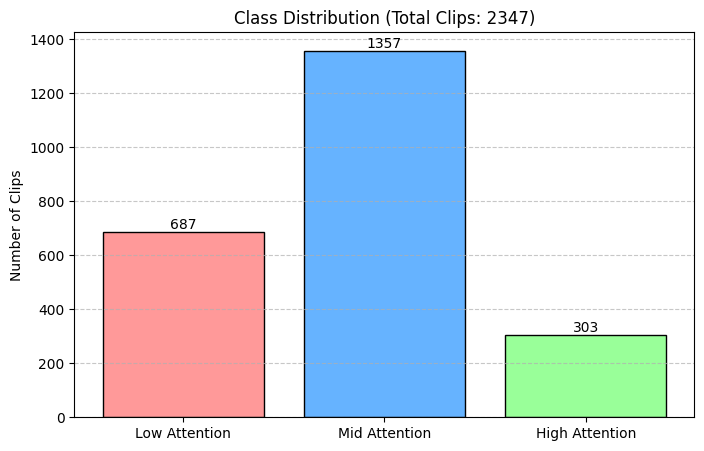

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
import seaborn as sns

# ================= CONFIGURATION =================
# Path to your processed .npy files
DATA_DIR = "/content/drive/MyDrive/Processed_Clips_v1"

# Class Labels (0, 1, 2)
CLASS_NAMES = ["Low Attention", "Mid Attention", "High Attention"]

# ================= ANALYSIS SCRIPT =================

def analyze_class_distribution(data_dir):
    print(f"Scanning {data_dir} for label files...")

    # Find all files ending in _y.npy
    label_files = glob.glob(os.path.join(data_dir, "*_y.npy"))

    if len(label_files) == 0:
        print("No label files found! Check your path.")
        return

    print(f"Found {len(label_files)} subject files.")

    # Aggregate all labels into one giant list
    all_labels = []
    subject_stats = {} # To store per-subject breakdown

    for f in label_files:
        # Extract subject name (e.g., "subject_01")
        subj_name = os.path.basename(f).replace("_y.npy", "")

        # Load labels
        y = np.load(f)
        all_labels.append(y)

        # Store individual stats
        unique, counts = np.unique(y, return_counts=True)
        stats = dict(zip(unique, counts))
        subject_stats[subj_name] = stats

    # Combine into one array
    total_y = np.concatenate(all_labels)

    # ================= CALCULATE STATS =================
    unique_classes, total_counts = np.unique(total_y, return_counts=True)
    total_dict = dict(zip(unique_classes, total_counts))

    total_samples = len(total_y)

    print("\n" + "="*40)
    print("      GLOBAL DATASET STATISTICS      ")
    print("="*40)
    print(f"Total Video Clips: {total_samples}")

    for cls_idx in [0, 1, 2]:
        count = total_dict.get(cls_idx, 0)
        percent = (count / total_samples) * 100
        print(f"Class {cls_idx} ({CLASS_NAMES[cls_idx]}): {count} clips ({percent:.2f}%)")

    # ================= VISUALIZATION =================

    # 1. Bar Chart
    plt.figure(figsize=(8, 5))
    colors = ['#ff9999', '#66b3ff', '#99ff99'] # Red, Blue, Green

    # Ensure we plot 0 for missing classes
    plot_counts = [total_dict.get(i, 0) for i in range(3)]

    bars = plt.bar(CLASS_NAMES, plot_counts, color=colors, edgecolor='black')

    # Add count labels on top of bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                 f'{int(height)}',
                 ha='center', va='bottom')

    plt.title(f'Class Distribution (Total Clips: {total_samples})')
    plt.ylabel('Number of Clips')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

analyze_class_distribution(DATA_DIR)

Loading subject_04_X.npy...

Data Shape (X): (58, 16, 224, 224, 3)
Labels Shape (y): (58,)
Class Distribution: (array([0, 1, 2]), array([ 4, 45,  9]))

Visualizing Clip #43 | Label: 1 (Mid)


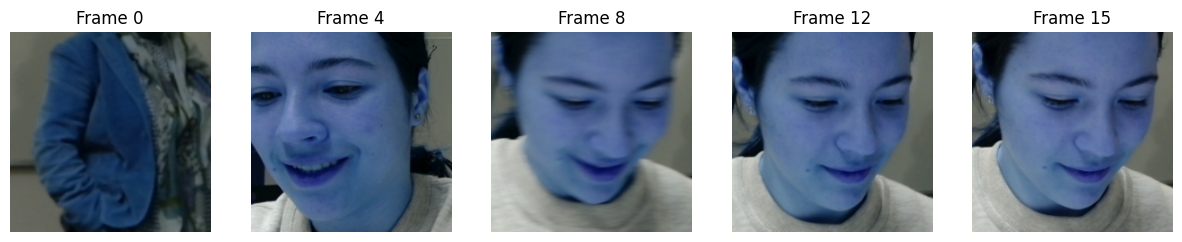

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

# CONFIGURATION
# Path to one of your processed subject files
# Make sure this matches the actual file name in your drive
DATA_PATH_X = "/content/drive/MyDrive/Processed_Clips_v1/subject_04_X.npy"
DATA_PATH_Y = "/content/drive/MyDrive/Processed_Clips_v1/subject_04_y.npy"

def inspect_data(x_path, y_path):
    # 1. Load the data
    if not os.path.exists(x_path) or not os.path.exists(y_path):
        print("Files not found! Check your paths.")
        return

    print(f"Loading {os.path.basename(x_path)}...")

    # mmap_mode='r' allows us to read large files without loading them entirely into RAM
    X = np.load(x_path, mmap_mode='r')
    y = np.load(y_path)

    # 2. Check Dimensions
    print(f"\nData Shape (X): {X.shape}")
    print(f"Labels Shape (y): {y.shape}")
    print(f"Class Distribution: {np.unique(y, return_counts=True)}")

    # Structure verification
    # Expecting (Num_Clips, 16, 224, 224, 3)
    if X.ndim != 5:
        print("WARNING: Data is not 5-dimensional! Something might be wrong.")

    # 3. Visualize a Random Clip
    # Pick a random index
    idx = np.random.randint(0, len(X))

    # We must copy the specific clip to RAM to plot it
    clip = X[idx]
    label = y[idx]

    label_map = {0: "Low", 1: "Mid", 2: "High"}
    print(f"\nVisualizing Clip #{idx} | Label: {label} ({label_map.get(label, 'Unknown')})")

    # Plot 5 frames from the 16-frame sequence (Start, Middle, End)
    frames_to_show = [0, 4, 8, 12, 15]

    fig, axes = plt.subplots(1, 5, figsize=(15, 5))
    for i, ax in enumerate(axes):
        frame_idx = frames_to_show[i]

        # NOTE: If you saved as uint8 (0-255), matplotlib handles it fine.
        # If you normalized to 0-1 float, it also handles it.
        ax.imshow(clip[frame_idx].astype('uint8'))
        ax.set_title(f"Frame {frame_idx}")
        ax.axis('off')

    plt.show()

# Run the function
inspect_data(DATA_PATH_X, DATA_PATH_Y)

Training on: cuda
Loading data from Drive...
Total Clips Loaded: (2347, 16, 224, 224, 3)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 186MB/s]


Starting Training...
Epoch [1/20] Train Loss: 1.0989 | Val Loss: 1.0811 | Val Acc: 51.91%
Epoch [2/20] Train Loss: 1.0606 | Val Loss: 1.0628 | Val Acc: 38.09%
Epoch [3/20] Train Loss: 1.0408 | Val Loss: 1.0625 | Val Acc: 42.34%
Epoch [4/20] Train Loss: 1.0113 | Val Loss: 1.0453 | Val Acc: 52.34%
Epoch [5/20] Train Loss: 0.9871 | Val Loss: 1.0301 | Val Acc: 47.23%
Epoch [6/20] Train Loss: 0.9517 | Val Loss: 1.0479 | Val Acc: 44.26%
Epoch [7/20] Train Loss: 0.9428 | Val Loss: 1.0207 | Val Acc: 43.62%
Epoch [8/20] Train Loss: 0.9078 | Val Loss: 1.0525 | Val Acc: 54.89%
Epoch [9/20] Train Loss: 0.8907 | Val Loss: 1.0048 | Val Acc: 44.68%
Epoch [10/20] Train Loss: 0.8553 | Val Loss: 1.0368 | Val Acc: 45.74%
Epoch [11/20] Train Loss: 0.8341 | Val Loss: 1.0340 | Val Acc: 48.30%
Epoch [12/20] Train Loss: 0.8071 | Val Loss: 1.0452 | Val Acc: 48.72%
Epoch [13/20] Train Loss: 0.7966 | Val Loss: 1.0245 | Val Acc: 44.47%
Epoch [14/20] Train Loss: 0.7694 | Val Loss: 1.0656 | Val Acc: 50.64%
Epoch [1

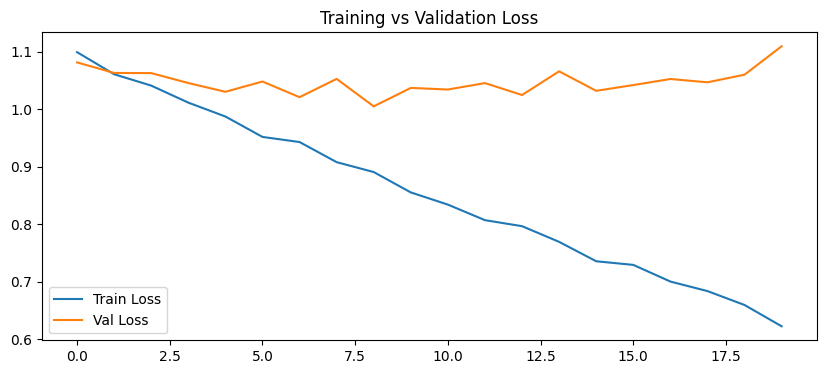


Classification Report:
              precision    recall  f1-score   support

         Low       0.41      0.70      0.51       137
         Mid       0.73      0.49      0.58       272
        High       0.30      0.25      0.27        61

    accuracy                           0.52       470
   macro avg       0.48      0.48      0.46       470
weighted avg       0.58      0.52      0.52       470



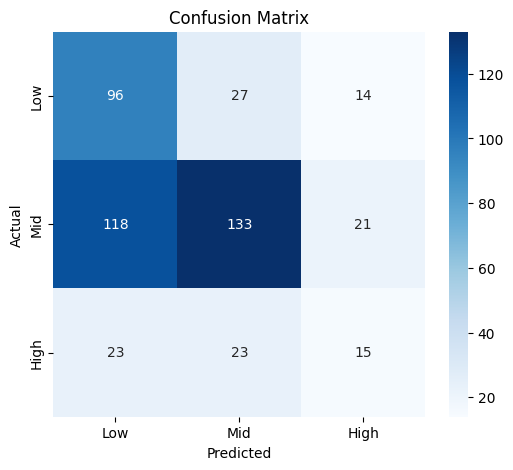

Model saved to Drive.


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix
import gc

# ================= CONFIGURATION =================
DATA_DIR = "/content/drive/MyDrive/Processed_Clips_v1"
BATCH_SIZE = 16          # Small batch size to save GPU memory
LEARNING_RATE = 1e-4     # Low LR for fine-tuning
EPOCHS = 20
IMG_SIZE = 224
SEQ_LENGTH = 16

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}")

# ================= 1. DATA LOADER =================

class VideoDataset(Dataset):
    def __init__(self, X_data, y_data):
        self.X = X_data # Expecting uint8 (0-255) to save RAM
        self.y = y_data

        # Standard ImageNet normalization
        self.transform = transforms.Compose([
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        # Get clip: (16, 224, 224, 3)
        clip = self.X[idx]
        label = self.y[idx]

        # Convert to Float Tensor and normalize (0-1)
        # Shape becomes (16, 3, 224, 224) for PyTorch
        clip = torch.from_numpy(clip).permute(0, 3, 1, 2).float() / 255.0

        # Apply Normalization to every frame
        # We flatten to (16, C, H, W) -> normalize -> keep shape
        normalized_clip = torch.stack([self.transform(frame) for frame in clip])

        return normalized_clip, label

def load_data(data_dir):
    print("Loading data from Drive...")
    x_files = sorted(glob.glob(os.path.join(data_dir, "*_X.npy")))
    y_files = sorted(glob.glob(os.path.join(data_dir, "*_y.npy")))

    if not x_files:
        raise ValueError("No data found! Check paths.")

    # Load and concatenate
    X_all = np.concatenate([np.load(f) for f in x_files], axis=0)
    y_all = np.concatenate([np.load(f) for f in y_files], axis=0)

    print(f"Total Clips Loaded: {X_all.shape}")
    return X_all, y_all

# Load Data
X_all, y_all = load_data(DATA_DIR)

# Stratified Split (Crucial for your Class 2 imbalance)
splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_idx, val_idx in splitter.split(X_all, y_all):
    X_train, X_val = X_all[train_idx], X_all[val_idx]
    y_train, y_val = y_all[train_idx], y_all[val_idx]

# Create Datasets
train_dataset = VideoDataset(X_train, y_train)
val_dataset = VideoDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# Clean up RAM (Delete large original arrays)
del X_all, y_all, X_train, X_val, y_train, y_val
gc.collect()

# ================= 2. MODEL ARCHITECTURE =================

class ResNetLSTM(nn.Module):
    def __init__(self, num_classes=3):
        super(ResNetLSTM, self).__init__()

        # 1. Feature Extractor (ResNet18)
        # We remove the last FC layer to get features
        resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        modules = list(resnet.children())[:-1] # Remove last layer
        self.cnn = nn.Sequential(*modules)

        # Freeze ResNet early layers (Optional: saves time/memory)
        for param in self.cnn.parameters():
            param.requires_grad = False

        # 2. Sequence Modeler (LSTM)
        self.lstm = nn.LSTM(input_size=512, hidden_size=128, num_layers=1, batch_first=True)

        # 3. Classifier
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        # Input: (Batch, Seq_Len, C, H, W)
        batch_size, seq_len, c, h, w = x.size()

        # Merge Batch and Sequence dims to feed into CNN
        # (Batch*16, 3, 224, 224)
        c_in = x.view(batch_size * seq_len, c, h, w)

        # Extract features
        c_out = self.cnn(c_in) # Output: (Batch*16, 512, 1, 1)
        c_out = c_out.view(batch_size, seq_len, -1) # (Batch, 16, 512)

        # Feed into LSTM
        # LSTM output: (Batch, 16, 128)
        r_out, (h_n, c_n) = self.lstm(c_out)

        # Take the output of the LAST frame in the sequence
        last_out = r_out[:, -1, :]

        # Classification
        out = self.fc(last_out)
        return out

model = ResNetLSTM(num_classes=3).to(device)

# ================= 3. TRAINING SETUP =================

# CLASS WEIGHTS (Calculated from your distribution: Low=1.14, Mid=0.58, High=2.58)
class_weights = torch.tensor([1.14, 0.58, 2.58]).float().to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# ================= 4. TRAINING LOOP =================

history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

print("Starting Training...")

for epoch in range(EPOCHS):
    # --- TRAIN ---
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)

    # --- VALIDATE ---
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_val_loss = val_loss / len(val_loader)
    val_accuracy = 100 * correct / total

    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['val_acc'].append(val_accuracy)

    print(f"Epoch [{epoch+1}/{EPOCHS}] "
          f"Train Loss: {avg_train_loss:.4f} | "
          f"Val Loss: {avg_val_loss:.4f} | "
          f"Val Acc: {val_accuracy:.2f}%")

print("Training Complete!")

# ================= 5. EVALUATION =================

# Plot Loss Curves
plt.figure(figsize=(10, 4))
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

# Confusion Matrix
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

# Report
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=["Low", "Mid", "High"]))

# Matrix Plot
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Low", "Mid", "High"],
            yticklabels=["Low", "Mid", "High"])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Save the Model
torch.save(model.state_dict(), '/content/drive/MyDrive/student_attention_model.pth')
print("Model saved to Drive.")

In [ ]:
import cv2
import torch
import mediapipe as mp
import numpy as np
import os
from torchvision import models, transforms
import torch.nn as nn
from google.colab.patches import cv2_imshow # Specific for Colab display

# ================= CONFIGURATION =================
# Path to a subject you want to test (e.g., subject_05 from test set)
TEST_SUBJECT_DIR = "/content/drive/MyDrive/Behaviour Dataset/subject_05/images"
MODEL_PATH = "/content/drive/MyDrive/student_attention_model.pth"
OUTPUT_VIDEO_PATH = "/content/drive/MyDrive/subject_05_demo.mp4"

# Parameters (Must match training!)
IMG_SIZE = 224
SEQ_LENGTH = 16
CLASSES = ["Low Attention", "Mid Attention", "High Attention"]
COLORS = [(0, 0, 255), (0, 255, 255), (0, 255, 0)] # Red, Yellow, Green

# Check Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ================= 1. RE-DEFINE MODEL =================
# (You must redefine the class to load the weights)
class ResNetLSTM(nn.Module):
    def __init__(self, num_classes=3):
        super(ResNetLSTM, self).__init__()
        resnet = models.resnet18(weights=None) # No need to download weights again
        modules = list(resnet.children())[:-1]
        self.cnn = nn.Sequential(*modules)
        self.lstm = nn.LSTM(input_size=512, hidden_size=128, num_layers=1, batch_first=True)
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        batch_size, seq_len, c, h, w = x.size()
        c_in = x.view(batch_size * seq_len, c, h, w)
        c_out = self.cnn(c_in)
        c_out = c_out.view(batch_size, seq_len, -1)
        r_out, _ = self.lstm(c_out)
        return self.fc(r_out[:, -1, :])

# Load Model
print("Loading Model...")
model = ResNetLSTM(num_classes=3).to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

# Preprocessing transforms
transform = transforms.Compose([
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ================= 2. VIDEO GENERATION LOOP =================

def create_demo_video(image_dir, output_path):
    # Get images sorted by time
    images = sorted(os.listdir(image_dir))
    # Filter only images
    images = [img for img in images if img.lower().endswith(('.jpg', '.png', '.jpeg'))]

    if not images:
        print("No images found to process.")
        return

    # Setup Video Writer
    first_frame = cv2.imread(os.path.join(image_dir, images[0]))
    h, w, _ = first_frame.shape
    fourcc = cv2.VideoWriter_fourcc(*'mp4v') # Codec for .mp4
    out = cv2.VideoWriter(output_path, fourcc, 10.0, (w, h)) # 10 FPS

    # Setup Face Detector
    mp_face = mp.solutions.face_detection
    detector = mp_face.FaceDetection(model_selection=1, min_detection_confidence=0.5)

    # Buffer for sliding window
    frame_buffer = [] # Holds cropped tensors
    prediction_buffer = "Initializing..." # Display text
    color_buffer = (255, 255, 255)

    last_box = None

    print(f"Processing {len(images)} frames into video...")

    for i, img_name in enumerate(images):
        path = os.path.join(image_dir, img_name)
        frame = cv2.imread(path)
        if frame is None: continue

        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        # --- 1. Detect Face ---
        results = detector.process(rgb_frame)
        crop = None

        if results.detections:
            det = results.detections[0].location_data.relative_bounding_box
            x = int(det.xmin * w); y = int(det.ymin * h)
            bw = int(det.width * w); bh = int(det.height * h)
            # Padding
            x, y = max(0, x-10), max(0, y-10)
            bw, bh = min(w-x, bw+20), min(h-y, bh+20)
            last_box = (x, y, bw, bh)
            crop = frame[y:y+bh, x:x+bw]
        elif last_box:
            # Impute
            x, y, bw, bh = last_box
            crop = frame[y:y+bh, x:x+bw]

        # --- 2. Prepare for Model ---
        if crop is not None:
            # Resize & Normalize
            try:
                crop_resized = cv2.resize(crop, (IMG_SIZE, IMG_SIZE))
                crop_tensor = torch.from_numpy(crop_resized).permute(2, 0, 1).float() / 255.0
                crop_normalized = transform(crop_tensor)
                frame_buffer.append(crop_normalized)
            except:
                pass # Skip bad crops

        # Manage Buffer
        if len(frame_buffer) > SEQ_LENGTH:
            frame_buffer.pop(0) # Keep strictly 16 frames

        # --- 3. Inference (Only when buffer is full) ---
        if len(frame_buffer) == SEQ_LENGTH:
            # Create batch of size 1: (1, 16, 3, 224, 224)
            input_seq = torch.stack(frame_buffer).unsqueeze(0).to(device)

            with torch.no_grad():
                outputs = model(input_seq)
                probs = torch.softmax(outputs, dim=1)
                pred_idx = torch.argmax(probs, dim=1).item()
                confidence = probs[0][pred_idx].item()

                prediction_buffer = f"{CLASSES[pred_idx]} ({confidence:.2f})"
                color_buffer = COLORS[pred_idx]

        # --- 4. Draw UI ---
        # Draw Box around face
        if last_box:
            x, y, bw, bh = last_box
            cv2.rectangle(frame, (x, y), (x+bw, y+bh), color_buffer, 2)

        # Draw Label Bar
        cv2.rectangle(frame, (0, 0), (w, 40), (0, 0, 0), -1) # Black Header
        cv2.putText(frame, f"AI Status: {prediction_buffer}", (10, 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, color_buffer, 2)

        out.write(frame)

        if i % 50 == 0: print(f"Processed frame {i}/{len(images)}")

    out.release()
    detector.close()
    print(f"Done! Video saved to: {output_path}")

# Run It
create_demo_video(TEST_SUBJECT_DIR, OUTPUT_VIDEO_PATH)

Loading Model...
Processing 2274 frames into video...
Processed frame 0/2274


/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


Processed frame 50/2274
Processed frame 100/2274
Processed frame 150/2274
Processed frame 200/2274
Processed frame 250/2274
Processed frame 300/2274
Processed frame 350/2274
Processed frame 400/2274
Processed frame 450/2274
Processed frame 500/2274
Processed frame 550/2274
Processed frame 600/2274
Processed frame 650/2274
Processed frame 700/2274
Processed frame 750/2274
Processed frame 800/2274
Processed frame 850/2274
Processed frame 900/2274
Processed frame 950/2274
Processed frame 1000/2274
Processed frame 1050/2274
Processed frame 1100/2274
Processed frame 1150/2274
Processed frame 1200/2274
Processed frame 1250/2274
Processed frame 1300/2274
Processed frame 1350/2274
Processed frame 1400/2274
Processed frame 1450/2274
Processed frame 1500/2274
Processed frame 1550/2274
Processed frame 1600/2274
Processed frame 1650/2274
Processed frame 1700/2274
Processed frame 1750/2274
Processed frame 1800/2274
Processed frame 1850/2274
Processed frame 1900/2274
Processed frame 1950/2274
Proces